House_price_prediction Using Linear, Lasso and Ridge regression 

Linear Regression

In [118]:
import numpy as np 
import pandas as pd 
from sklearn.linear_model import LinearRegression

In [119]:
df=pd.read_csv("data.csv")
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [120]:
df.shape

(4600, 18)

In [121]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [122]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [123]:
df=df.drop(['date', 'street', 'country'], axis=1)

In [124]:
df = df[df['price'] <= df['price'].quantile(0.99)]

In [125]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop('price',axis=1),drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=40)

In [126]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

y_pred_linear = lr_model.predict(X_test)

In [127]:
from sklearn.metrics import *
mae = mean_absolute_error(y_test,y_pred_linear)
mse = mean_squared_error(y_test,y_pred_linear)
r2 = r2_score(y_test,y_pred_linear)
mape = mean_absolute_percentage_error(y_test,y_pred_linear)
print("Linear Regression")
print(mae)
print(mse)
print(r2)
print(mape)

Linear Regression
94122.56028280636
28523115339.425083
0.694199923726893
3.954643232337829e+19


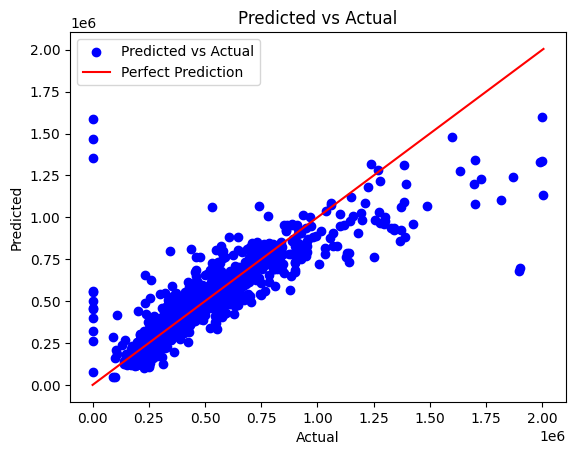

In [128]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_linear, color='blue', label='Predicted vs Actual')

max_val = max(max(y_test), max(y_pred_linear))
min_val = min(min(y_test), min(y_pred_linear))

plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Perfect Prediction')

plt.title('Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

Polynomial Regression 

In [129]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

polymodel = LinearRegression()

polymodel.fit(X_train_p,y_train_p)


y_pred_poly = polymodel.predict(X_test_p)

In [130]:
mae = mean_absolute_error(y_test_p,y_pred_poly)
mse = mean_squared_error(y_test_p,y_pred_poly)
r2 = r2_score(y_test_p,y_pred_poly)
mape = mean_absolute_percentage_error(y_test_p,y_pred_poly)
print("Polynomial")
print(mae)
print(mse)
print(r2)
print(mape)

Polynomial
108543.50092094953
37106091415.220116
0.5608996010317212
3.0884654655577473e+19


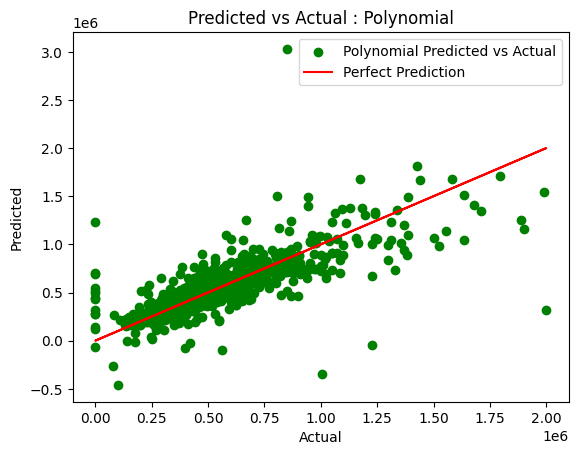

In [131]:
plt.scatter(y_test_p, y_pred_poly, color='green', label='Polynomial Predicted vs Actual')

# Perfect prediction line
max_val = max(max(y_test_p), max(y_pred_poly))
min_val = min(min(y_test_p), min(y_pred_poly))
plt.plot(y_test_p,y_test_p, color='red', label='Perfect Prediction')

plt.title('Predicted vs Actual : Polynomial')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()

L1 Regression

Lasso Regression (Least Absolute Shrinkage and Selection Operator)

In [132]:
# from sklearn.linear_model import LassoCV

# lasso_cv = LassoCV(cv=5, random_state=42)
# lasso_cv.fit(X_train, y_train)
# print("Best alpha:", lasso_cv.alpha_)

In [133]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LassoCV
# import numpy as np

# # Scale features
# scaler_X = StandardScaler()
# X_train_scaled = scaler_X.fit_transform(X_train)
# X_test_scaled = scaler_X.transform(X_test)

# # Scale target (optional but helps with huge numbers)
# y_train_scaled = np.log1p(y_train)   # log-transform
# y_test_scaled = np.log1p(y_test)

# # Fit LassoCV
# lasso_cv = LassoCV(cv=5, random_state=42)
# lasso_cv.fit(X_train_scaled, y_train_scaled)

# print("Best alpha (scaled):", lasso_cv.alpha_)

In [134]:
from sklearn.linear_model import Lasso

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize Lasso regression with alpha=0.1 (regularization strength)
ls_model = Lasso(alpha=0.025)

# 4. Train the model on training data
ls_model.fit(X_train_lasso, y_train_lasso)

# 5. Predict on test data
y_pred_lasso = ls_model.predict(X_test_lasso)

c:\Users\mansu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.426e+13, tolerance: 3.175e+10
  model = cd_fast.enet_coordinate_descent(


In [135]:
mae = mean_absolute_error(y_test_lasso,y_pred_lasso)
mse = mean_squared_error(y_test_lasso,y_pred_lasso)
r2 = r2_score(y_test_lasso,y_pred_lasso)
mape = mean_absolute_percentage_error(y_test_lasso,y_pred_lasso)
print("Lasso")
print(mae)
print(mse)
print(r2)
print(mape)

Lasso
93449.53783343255
23022868582.7942
0.7275554930597582
3.733264264728315e+19


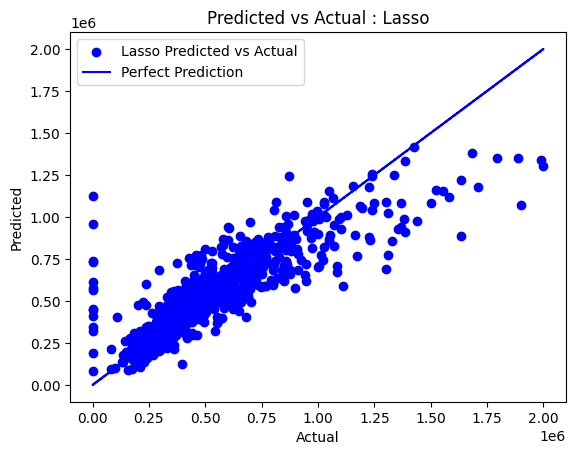

In [136]:
plt.scatter(y_test_lasso, y_pred_lasso, color='blue', label='Lasso Predicted vs Actual')

# Perfect prediction line
max_val = max(max(y_test_lasso), max(y_pred_lasso))
min_val = min(min(y_test_lasso), min(y_pred_lasso))
plt.plot(y_test_lasso,y_test_lasso, color='blue', label='Perfect Prediction')

plt.title('Predicted vs Actual : Lasso')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()

L2 regreesion 

Ridge Regression

In [137]:
from sklearn.linear_model import Ridge

# Split dataset
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Ridge regression with alpha = 0.5
ridge_model = Ridge(alpha=0.5, random_state=42)
ridge_model.fit(X_train_ridge, y_train_ridge)

# Predict on test set
y_pred_ridge= ridge_model.predict(X_test_ridge)


In [138]:
mae = mean_absolute_error(y_test_ridge,y_pred_ridge)
mse = mean_squared_error(y_test_ridge,y_pred_ridge)
r2 = r2_score(y_test_ridge,y_pred_ridge)
mape = mean_absolute_percentage_error(y_test_ridge,y_pred_ridge)
print("Ridge")
print(mae)
print(mse)
print(r2)
print(mape)

Ridge
93595.97374052394
22997922959.759182
0.7278506907647554
3.74578528043296e+19


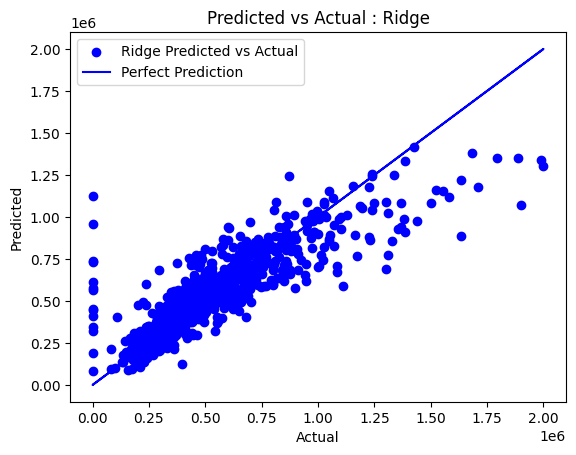

In [139]:
plt.scatter(y_test_lasso, y_pred_lasso, color='blue', label='Ridge Predicted vs Actual')

# Perfect prediction line
max_val = max(max(y_test_ridge), max(y_pred_ridge))
min_val = min(min(y_test_ridge), min(y_pred_ridge))
plt.plot(y_test_ridge,y_test_ridge, color='blue', label='Perfect Prediction')

plt.title('Predicted vs Actual : Ridge')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()

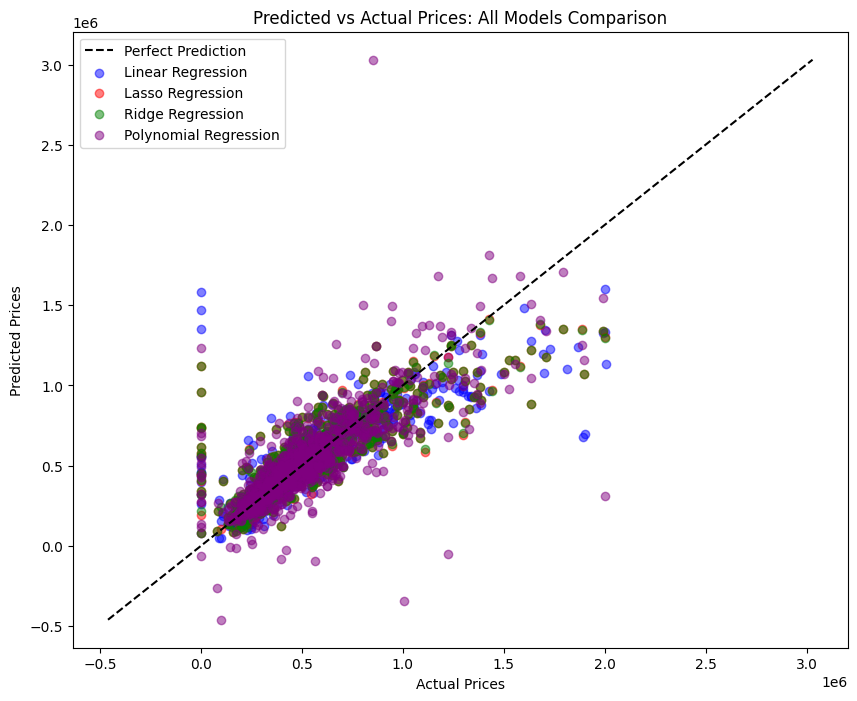

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Perfect prediction line (y = x)
max_val = max(max(y_test), max(y_pred_linear), max(y_pred_lasso), max(y_pred_ridge), max(y_pred_poly))
min_val = min(min(y_test), min(y_pred_linear), min(y_pred_lasso), min(y_pred_ridge), min(y_pred_poly))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')

# Linear Regression
plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.5, label='Linear Regression')

# Lasso Regression
plt.scatter(y_test_lasso, y_pred_lasso, color='red', alpha=0.5, label='Lasso Regression')

# Ridge Regression
plt.scatter(y_test_ridge, y_pred_ridge, color='green', alpha=0.5, label='Ridge Regression')

# Polynomial Regression
plt.scatter(y_test_p, y_pred_poly, color='purple', alpha=0.5, label='Polynomial Regression')

# Labels and title
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs Actual Prices: All Models Comparison')
plt.legend()
plt.show()

In [141]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": ls_model.coef_
})

print(coef_df)

               Feature         Linear          Ridge          Lasso
0             bedrooms  -12122.188722   -7396.969043   -7009.689907
1            bathrooms   11029.492546   15685.343282   15183.118845
2          sqft_living     103.198153      98.628872     176.624572
3             sqft_lot       0.126955       0.138453       0.143409
4               floors  -17120.598989  -10271.469324  -11509.890359
..                 ...            ...            ...            ...
126  statezip_WA 98188 -214601.679956 -202342.793461 -153604.266684
127  statezip_WA 98198 -229805.919600 -197109.728960 -165974.926344
128  statezip_WA 98199  168553.567408  140910.255950  229710.564084
129  statezip_WA 98288   26661.412455  -41828.240546   45844.579260
130  statezip_WA 98354   59618.382336  -15518.799949  100155.511962

[131 rows x 4 columns]


Comparision

Performance Comparison Table
| Model             | MAE    | MSE     | R² Score          |
| ----------------- | ------ | ------- | ----------------- |
| Linear Regression | 94,122 | 2.85e10 | 0.694             |
| Lasso Regression  | 93,449 | 2.30e10 | 0.7275            |
| Ridge Regression  | 93,595 | 2.29e10 | **0.7278 (Best)** |


Ridge Regression performed the best in this project because it achieved the highest R² score and slightly lower error than the other models. It improves model stability by shrinking coefficients and reducing overfitting.

Lasso Regression also performed very well but did not remove any features, which indicates that all input features are important for predicting house prices.

Linear Regression worked as a baseline model but had slightly higher prediction error compared to Ridge and Lasso.

Overall, Ridge Regression is the best model for this dataset, although all three models perform similarly.